# Causal Forest DML & Policy Learning — Optimal Scholarship Assignment

This notebook extends notebooks 3 (Double Post-LASSO) and 4 (Double ML) by:

1. Estimating **heterogeneous treatment effects** (CATE) of scholarships on graduation using **CausalForestDML** (Wager & Athey, 2018)
2. Designing an **optimal scholarship allocation policy** under budget constraints (Kitagawa & Tetenov, 2018; Athey & Wager, 2021)

**Sample:** Graduate + Dropout students only (`df_resolved`, n ≈ 3,630)  
**Treatment:** Scholarship holder (binary)  
**Outcome:** Y = 1 if Graduate (we target graduation, not dropout)

---

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.ensemble import (
    GradientBoostingRegressor, GradientBoostingClassifier,
    RandomForestClassifier,
)
from sklearn.tree import DecisionTreeClassifier, plot_tree
from econml.dml import CausalForestDML

sns.set_theme(style="whitegrid")
np.random.seed(42)


Libraries loaded successfully.


## 1. Data Loading & Sample Construction

We load the UCI dataset and split it into:
- `df_resolved`: students with a known outcome (Graduate or Dropout) — used for causal estimation
- `df_enrolled`: students still enrolled — used to apply the policy

**Outcome is graduation** (`Y = 1 if Graduate`), not dropout. This means positive CATE = scholarship improves graduation probability.

**Important:** `W_confounders` excludes all post-enrollment academic performance variables (semester grades, validated units) to avoid conditioning on mediators.

In [ ]:
from ucimlrepo import fetch_ucirepo

dataset = fetch_ucirepo(id=697)
X_data = dataset.data.features
y_data = dataset.data.targets

df = pd.concat([X_data, y_data], axis=1)
df.columns = df.columns.str.strip()

print(f"Full dataset: {df.shape[0]} students, {df.shape[1]} features")
print(f"\nTarget distribution:")
print(df['Target'].value_counts())

Full dataset: 4424 students, 37 features

Target distribution:
Target
Graduate    2209
Dropout     1421
Enrolled     794
Name: count, dtype: int64


In [ ]:
treatment = 'Scholarship holder'

# Pre-treatment confounders only (no post-enrollment academic performance)
W_confounders = [
    'Marital Status', "Mother's qualification", "Father's qualification",
    "Mother's occupation", "Father's occupation",
    'Nacionality', 'Gender', 'Age at enrollment',
    'Displaced', 'Educational special needs', 'International',
    'Application mode', 'Application order', 'Course',
    'Daytime/evening attendance', 'Previous qualification',
]
W_precision = ['Admission grade', 'Previous qualification (grade)']
W_all = W_confounders + W_precision

# Outcome: graduation (not dropout)
df['Graduate'] = (df['Target'] == 'Graduate').astype(int)

# Split: resolved (known outcome) vs enrolled (unknown outcome)
df_resolved = df[df['Target'].isin(['Graduate', 'Dropout'])].copy().reset_index(drop=True)
df_enrolled  = df[df['Target'] == 'Enrolled'].copy().reset_index(drop=True)

print(f"df_resolved (Graduate + Dropout): {len(df_resolved)} students")
print(f"  → Graduate rate:    {df_resolved['Graduate'].mean()*100:.1f}%")
print(f"  → Scholarship rate: {df_resolved[treatment].mean()*100:.1f}%")
print(f"\ndf_enrolled (Enrolled): {len(df_enrolled)} students")
print(f"  → Scholarship rate: {df_enrolled[treatment].mean()*100:.1f}%")
print(f"\nW_confounders ({len(W_confounders)} vars): {W_confounders}")
print(f"W_precision   ({len(W_precision)} vars): {W_precision}")

df_resolved (Graduate + Dropout): 3630 students
  → Graduate rate:    60.9%
  → Scholarship rate: 26.7%

df_enrolled (Enrolled): 794 students
  → Scholarship rate: 16.4%

W_confounders (16 vars): ['Marital Status', "Mother's qualification", "Father's qualification", "Mother's occupation", "Father's occupation", 'Nacionality', 'Gender', 'Age at enrollment', 'Displaced', 'Educational special needs', 'International', 'Application mode', 'Application order', 'Course', 'Daytime/evening attendance', 'Previous qualification']
W_precision   (2 vars): ['Admission grade', 'Previous qualification (grade)']


## 2. CausalForestDML — Heterogeneous Treatment Effects (CATE)

**CausalForestDML** (Wager & Athey 2018 + Chernozhukov et al. 2018) estimates individual-level treatment effects:

$$\hat{\tau}(W_i) = \mathbb{E}[Y_i(1) - Y_i(0) \mid W_i]$$

The algorithm uses **5-fold cross-fitting** to fit nuisance models $\hat{\ell}(W) = \mathbb{E}[Y \mid W]$ and $\hat{m}(W) = \mathbb{E}[D \mid W]$, then fits a causal forest on the residuals.

We use **GBR + GBC** as nuisance learners — the best-performing pair from notebook 4 (lowest combined nuisance loss).

In [6]:
X_resolved = df_resolved[W_confounders].values
Y_res = df_resolved['Graduate'].values.astype(float)
D_res = df_resolved[treatment].values.astype(float)

est = CausalForestDML(
    model_y=GradientBoostingRegressor(n_estimators=100, max_depth=3, random_state=42),
    model_t=GradientBoostingClassifier(n_estimators=100, max_depth=3, random_state=42),
    discrete_treatment=True,
    n_estimators=1000,
    random_state=42,
    cv=5,
    verbose=0,
)
est.fit(Y_res, D_res, X=X_resolved)

tau_hat = est.effect(X_resolved).flatten()
df_resolved['tau_hat'] = tau_hat

print(f"CATE estimated for {len(tau_hat)} students")
print(f"  Mean CATE (≈ ATE):     {tau_hat.mean():+.4f}")
print(f"  Std CATE:              {tau_hat.std():.4f}")
print(f"  Min / Max:             {tau_hat.min():+.4f} / {tau_hat.max():+.4f}")
print(f"  % with positive CATE: {(tau_hat > 0).mean()*100:.1f}%")

NameError: name 'df_resolved' is not defined

NameError: name 'tau_hat' is not defined

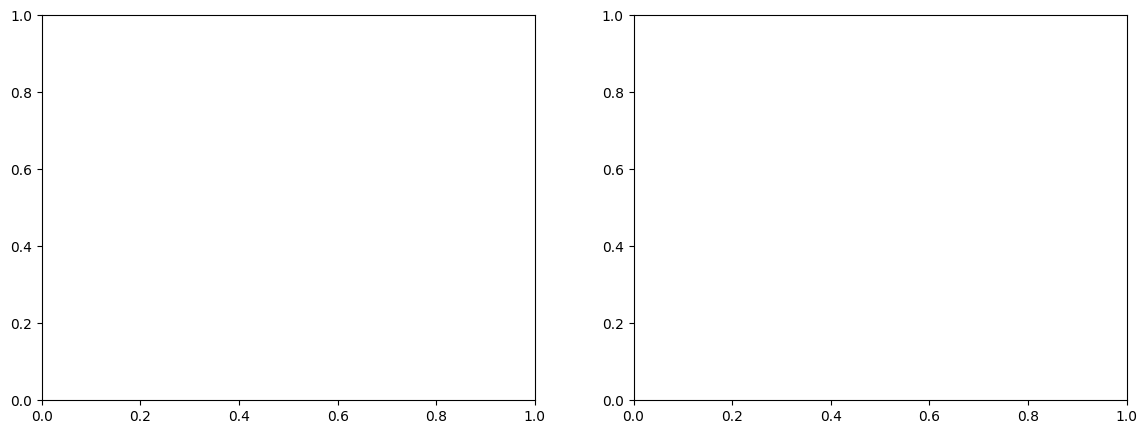

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Panel 1: CATE histogram
ax = axes[0]
ax.hist(tau_hat, bins=60, color='#85B7EB', edgecolor='white', alpha=0.85)
ax.axvline(tau_hat.mean(), color='#E24B4A', linestyle='--', lw=2,
           label=f'ATE = {tau_hat.mean():+.4f}')
ax.axvline(0, color='gray', linestyle=':', lw=1.5, alpha=0.7)
ax.set_xlabel('Estimated CATE (effect on graduation probability)')
ax.set_ylabel('Count')
ax.set_title('Distribution of Individual Treatment Effects')
ax.legend()

# Panel 2: Mean CATE by course
ax = axes[1]
cate_by_course = df_resolved.groupby('Course')['tau_hat'].mean().sort_values()
colors_bar = ['#0F6E56' if v > 0 else '#E24B4A' for v in cate_by_course]
ax.barh(cate_by_course.index.astype(str), cate_by_course.values, color=colors_bar)
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('Mean CATE')
ax.set_title('Mean CATE by Course Code')

plt.tight_layout()
plt.show()

## 3. Sensitivity Analysis — Confidence Intervals

We compute **90% confidence intervals** for each CATE estimate using the CausalForest's built-in honesty-based variance estimation. This shows which individual estimates are statistically distinguishable from zero.

90% CI analysis:
  Significantly positive CATE (CI > 0): 3268 (90.0%)
  Significantly negative CATE (CI < 0): 0 (0.0%)
  Inconclusive (CI crosses 0):           362 (10.0%)


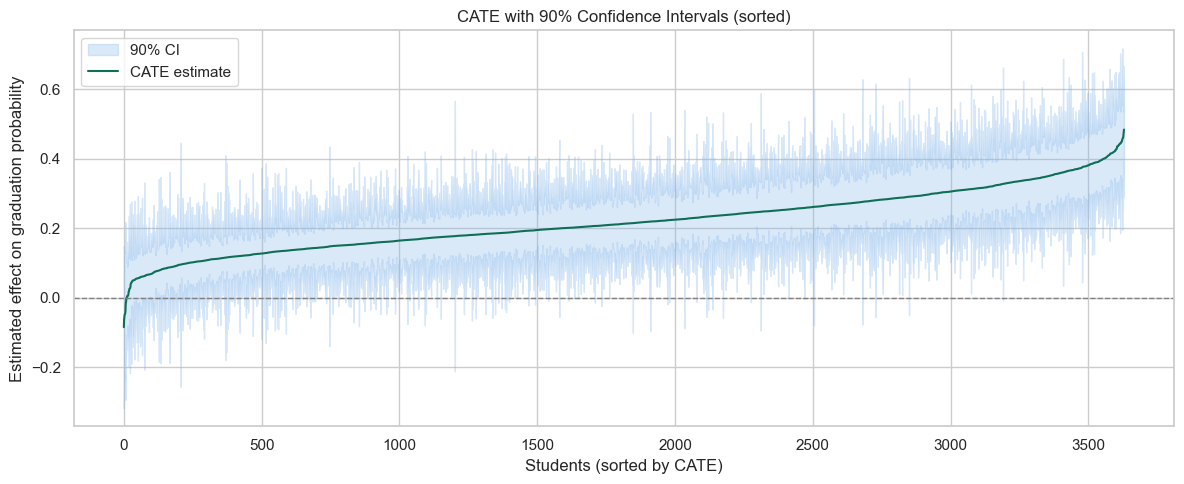

In [6]:
tau_lb, tau_ub = est.effect_interval(X_resolved, alpha=0.1)
tau_lb = tau_lb.flatten()
tau_ub = tau_ub.flatten()

sig_positive = (tau_lb > 0).sum()
sig_negative = (tau_ub < 0).sum()
inconclusive = len(tau_hat) - sig_positive - sig_negative

print(f"90% CI analysis:")
print(f"  Significantly positive CATE (CI > 0): {sig_positive} ({sig_positive/len(tau_hat)*100:.1f}%)")
print(f"  Significantly negative CATE (CI < 0): {sig_negative} ({sig_negative/len(tau_hat)*100:.1f}%)")
print(f"  Inconclusive (CI crosses 0):           {inconclusive} ({inconclusive/len(tau_hat)*100:.1f}%)")

fig, ax = plt.subplots(figsize=(12, 5))
sorted_idx = np.argsort(tau_hat)
ax.fill_between(range(len(tau_hat)), tau_lb[sorted_idx], tau_ub[sorted_idx],
                alpha=0.3, color='#85B7EB', label='90% CI')
ax.plot(range(len(tau_hat)), tau_hat[sorted_idx], color='#0F6E56', lw=1.5, label='CATE estimate')
ax.axhline(0, color='gray', linestyle='--', lw=1)
ax.set_xlabel('Students (sorted by CATE)')
ax.set_ylabel('Estimated effect on graduation probability')
ax.set_title('CATE with 90% Confidence Intervals (sorted)')
ax.legend()
plt.tight_layout()
plt.show()

## 8. Policy Learning: Optimal Scholarship Assignment

### 8.1 Setup & Problem Formulation

We have CATE estimates $\hat{\tau}(W_i)$ from the Causal Forest on `df_resolved`. The goal is to find the assignment policy $\pi^*: W \to \{0, 1\}$ that **maximizes expected graduation rate**:

$$\pi^* = \arg\max_{\pi \in \Pi_B} \; \frac{1}{n}\sum_i \hat{\tau}(W_i) \cdot \pi(W_i)$$

subject to a **budget constraint**: assign scholarships to the same total number of students as currently observed ($B = \sum_i D_i$).

This is the framework of **Kitagawa & Tetenov (2018)** and **Athey & Wager (2021)**. Under a budget constraint, the optimal policy is to assign to the $B$ students with the highest estimated CATE.

In [7]:
# Budget = same number of scholarships as currently observed in df_resolved
B = df_resolved[treatment].sum()
print(f"Budget constraint: {B} scholarships ({B/len(df_resolved)*100:.1f}% of resolved students)")
print(f"Observed scholarship rate: {df_resolved[treatment].mean()*100:.1f}%")

Budget constraint: 969 scholarships (26.7% of resolved students)
Observed scholarship rate: 26.7%


### 8.2 CATE-Threshold Policy (Simple Optimal Policy)

Under a budget constraint, the optimal policy is to rank students by estimated CATE (descending) and assign scholarships to the top $B$. This directly solves the optimization problem above.

In [8]:
# Rank students by CATE (highest benefit first)
df_resolved['rank'] = df_resolved['tau_hat'].rank(ascending=False, method='first')

# Optimal policy: top B students get scholarship
df_resolved['pi_star'] = (df_resolved['rank'] <= B).astype(int)

# Observed policy
df_resolved['pi_obs'] = df_resolved[treatment]

# Verify budget constraint
assert df_resolved['pi_star'].sum() == B, "Budget constraint violated!"

print(f"Optimal policy assigns {df_resolved['pi_star'].sum()} scholarships (same as observed: {df_resolved['pi_obs'].sum()})")
print(f"\nReassignment breakdown:")
print(f"  Keep scholarship:    {((df_resolved['pi_obs']==1) & (df_resolved['pi_star']==1)).sum()}")
print(f"  Keep no scholarship: {((df_resolved['pi_obs']==0) & (df_resolved['pi_star']==0)).sum()}")
print(f"  Gain scholarship:    {((df_resolved['pi_obs']==0) & (df_resolved['pi_star']==1)).sum()}")
print(f"  Lose scholarship:    {((df_resolved['pi_obs']==1) & (df_resolved['pi_star']==0)).sum()}")

Optimal policy assigns 969 scholarships (same as observed: 969)

Reassignment breakdown:
  Keep scholarship:    179
  Keep no scholarship: 1871
  Gain scholarship:    790
  Lose scholarship:    790


### 8.3 Policy Tree — Interpretable Assignment Rules

A **policy tree** approximates the CATE-threshold policy with a shallow decision tree, providing actionable rules the polytechnic can implement without running ML models per student.

We try `econml.policy.PolicyTree` (which directly maximizes welfare) and fall back to `sklearn.tree.DecisionTreeClassifier` fitted on the `pi_star` labels.

In [9]:
X_tree = df_resolved[W_confounders].values
using_econml_tree = False

try:
    from econml.policy import PolicyTree
    policy_tree = PolicyTree(max_depth=3, min_samples_leaf=50, random_state=42)
    policy_tree.fit(X_tree, tau_hat)
    pi_tree = policy_tree.predict(X_tree)
    using_econml_tree = True
    print("Using econml.policy.PolicyTree")
except Exception as e:
    print(f"PolicyTree unavailable ({e}), using sklearn fallback")
    policy_tree = DecisionTreeClassifier(max_depth=3, min_samples_leaf=50, random_state=42)
    policy_tree.fit(df_resolved[W_confounders], df_resolved['pi_star'])
    pi_tree = policy_tree.predict(df_resolved[W_confounders])

print(f"Policy tree assigns {int(pi_tree.sum())} scholarships")
print(f"Agreement with CATE-threshold policy: {(pi_tree == df_resolved['pi_star'].values).mean()*100:.1f}%")

Using econml.policy.PolicyTree
Policy tree assigns 0 scholarships
Agreement with CATE-threshold policy: 73.3%


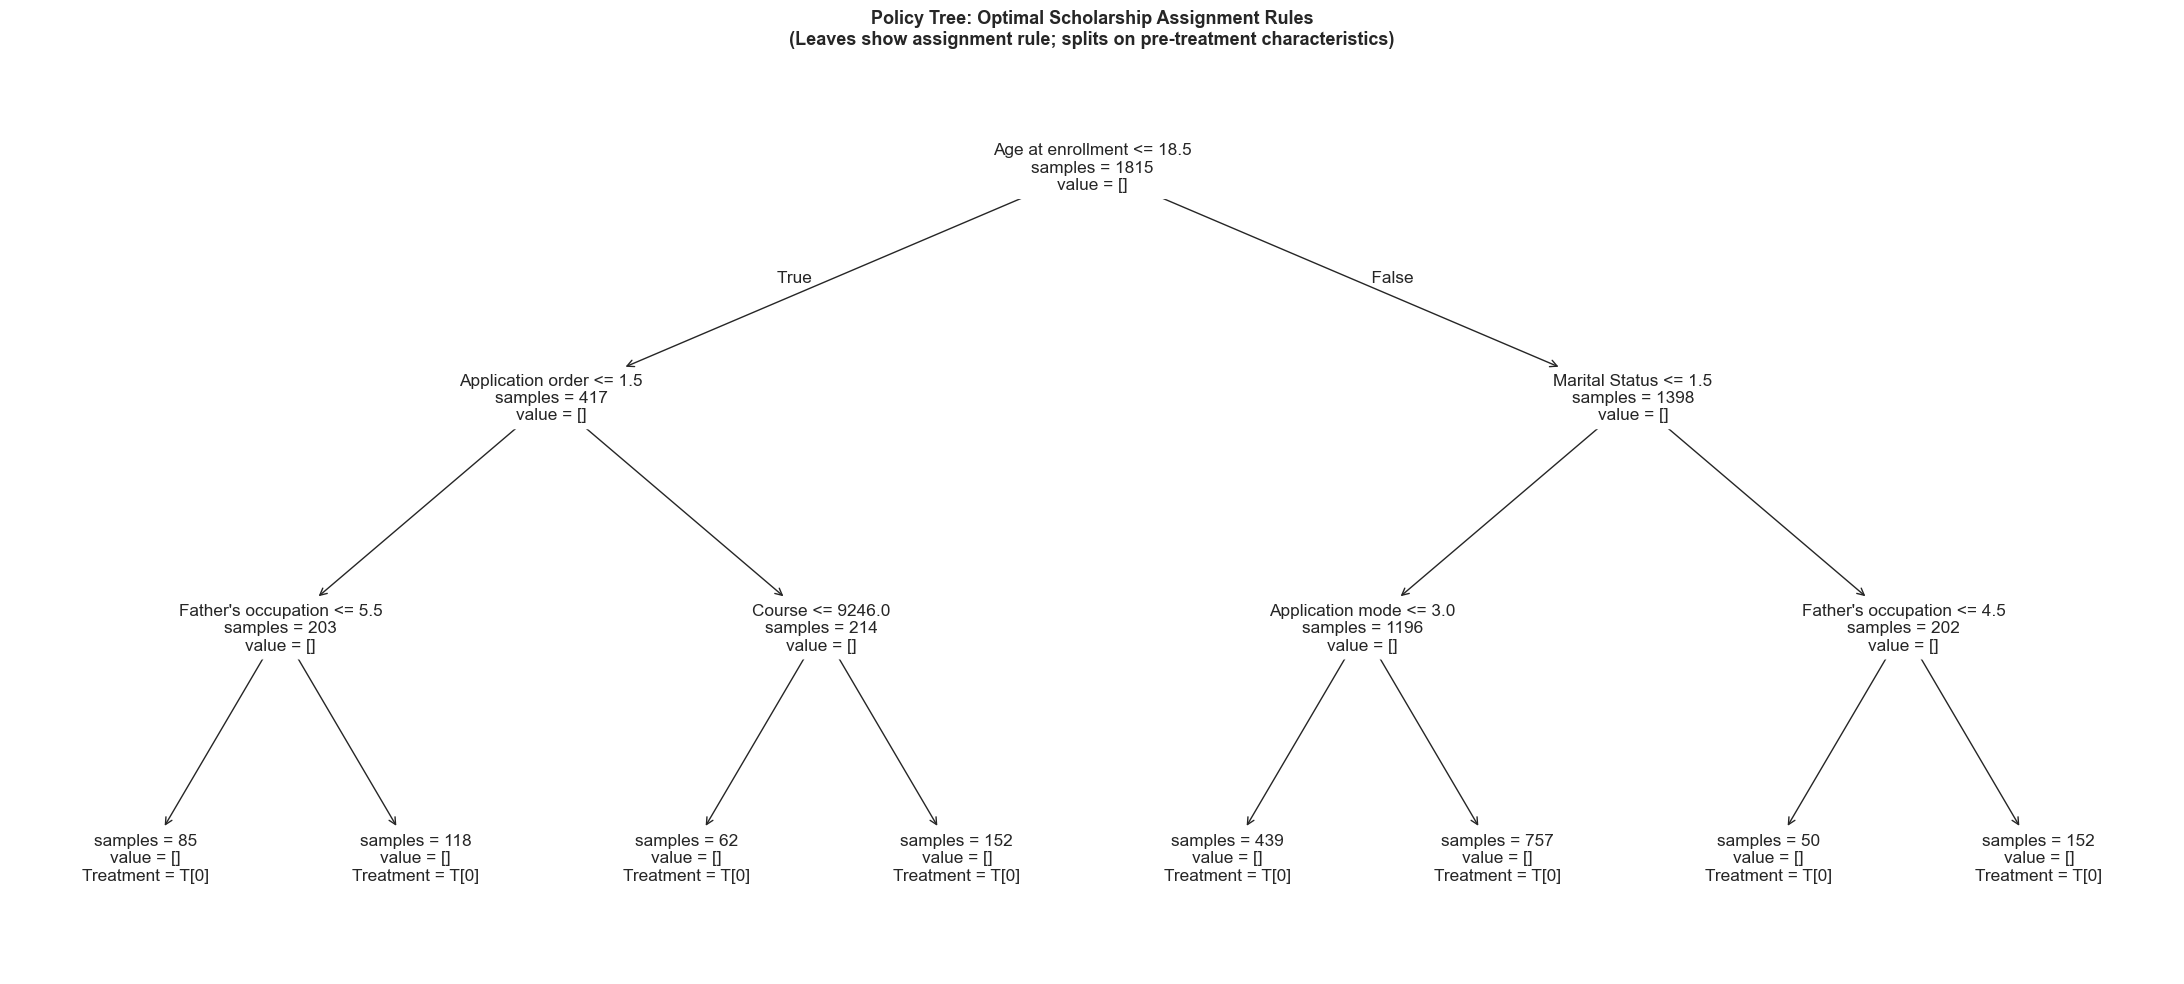

In [10]:
fig, ax = plt.subplots(figsize=(22, 10))

try:
    if using_econml_tree:
        policy_tree.plot(feature_names=W_confounders, ax=ax)
    else:
        plot_tree(policy_tree, feature_names=W_confounders,
                  class_names=['No scholarship', 'Scholarship'],
                  filled=True, rounded=True, ax=ax, fontsize=9)
except Exception as e:
    ax.text(0.5, 0.5, f"Tree visualization unavailable:\n{e}",
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

ax.set_title("Policy Tree: Optimal Scholarship Assignment Rules\n"
             "(Leaves show assignment rule; splits on pre-treatment characteristics)",
             fontsize=13, fontweight='bold')
plt.tight_layout()
plt.show()

### 8.4 Policy Evaluation — Expected Graduation Rates

We evaluate each policy using the **CATE plug-in estimator**:

$$\hat{V}(\pi) = \frac{1}{n} \sum_i \left[\hat{\mu}_0(W_i) + \hat{\tau}(W_i) \cdot \pi(W_i)\right]$$

where $\hat{\mu}_0(W_i) = \mathbb{E}[Y \mid D=0, W=W_i]$ is the **baseline graduation probability** (without scholarship), estimated by fitting LightGBM on the untreated subsample of `df_resolved`.

In [11]:
# Fit mu_0 model on untreated subsample
untreated = df_resolved[df_resolved[treatment] == 0]
mu0_model = RandomForestClassifier(n_estimators=500, max_depth=10,
                                    random_state=42, n_jobs=-1)
mu0_model.fit(untreated[W_all], untreated['Graduate'])
mu0_hat = mu0_model.predict_proba(df_resolved[W_all])[:, 1]

print(f"mu0 model trained on {len(untreated)} untreated students")
print(f"  Mean baseline grad. prob (untreated): {mu0_hat[df_resolved[treatment]==0].mean():.3f}")
print(f"  Mean baseline grad. prob (treated):   {mu0_hat[df_resolved[treatment]==1].mean():.3f}")

mu0 model trained on 2661 untreated students
  Mean baseline grad. prob (untreated): 0.517
  Mean baseline grad. prob (treated):   0.642


In [12]:
def expected_graduation(mu0, tau, pi):
    return np.mean(mu0 + tau * pi)

policies = {
    'No scholarships':          np.zeros(len(df_resolved)),
    'Observed assignment':      df_resolved['pi_obs'].values,
    'Optimal (CATE threshold)': df_resolved['pi_star'].values,
    'Optimal (policy tree)':    pi_tree,
}

results_pl = []
for name, pi in policies.items():
    grad_rate = expected_graduation(mu0_hat, tau_hat, pi)
    n_scholarships = int(pi.sum())
    results_pl.append({
        'Policy':                       name,
        'Scholarships assigned':        n_scholarships,
        'Scholarship rate (%)':         round(n_scholarships / len(df_resolved) * 100, 1),
        'Expected graduation rate (%)': round(grad_rate * 100, 1),
    })

results_df = pd.DataFrame(results_pl)
obs_rate = results_df.loc[results_df['Policy'] == 'Observed assignment',
                          'Expected graduation rate (%)'].values[0]
results_df['Δ vs observed (pp)'] = (results_df['Expected graduation rate (%)'] - obs_rate).round(1)

print(results_df.to_string(index=False))

                  Policy  Scholarships assigned  Scholarship rate (%)  Expected graduation rate (%)  Δ vs observed (pp)
         No scholarships                      0                   0.0                          55.0                -5.5
     Observed assignment                    969                  26.7                          60.5                 0.0
Optimal (CATE threshold)                    969                  26.7                          63.8                 3.3
   Optimal (policy tree)                      0                   0.0                          55.0                -5.5


### 8.5 Who Gets Reassigned? Profile Analysis

We classify students into three groups based on how their scholarship status changes under the optimal policy:
- **Gain scholarship**: currently untreated, targeted by optimal policy
- **Lose scholarship**: currently treated, dropped by optimal policy
- **Keep status**: no change

Profiling these groups reveals which student characteristics drive the reallocation.

In [13]:
df_resolved['reassignment'] = 'Keep status'
df_resolved.loc[(df_resolved['pi_obs'] == 0) & (df_resolved['pi_star'] == 1), 'reassignment'] = 'Gain scholarship'
df_resolved.loc[(df_resolved['pi_obs'] == 1) & (df_resolved['pi_star'] == 0), 'reassignment'] = 'Lose scholarship'

print(df_resolved['reassignment'].value_counts())

profile_cols = ['Course', 'Age at enrollment', 'Gender', 'Displaced',
                'Admission grade', 'Previous qualification (grade)', 'tau_hat']
profile = df_resolved.groupby('reassignment')[profile_cols].mean().round(3)
print("\nMean characteristics by reassignment group:")
print(profile)

reassignment
Keep status         2050
Gain scholarship     790
Lose scholarship     790
Name: count, dtype: int64

Mean characteristics by reassignment group:
                    Course  Age at enrollment  Gender  Displaced  \
reassignment                                                       
Gain scholarship  8895.530             30.556   0.509      0.261   
Keep status       8789.269             22.246   0.349      0.604   
Lose scholarship  8980.354             19.519   0.167      0.695   

                  Admission grade  Previous qualification (grade)  tau_hat  
reassignment                                                                
Gain scholarship          125.418                         130.978    0.331  
Keep status               127.720                         133.018    0.194  
Lose scholarship          128.065                         134.611    0.178  


### 8.6 Reallocation by Course — Key Visualization

The chart below compares scholarship rates by study programme under the observed vs. optimal policy. Programmes are sorted by their observed dropout rate (highest at top) — high-dropout programmes where the scholarship has large treatment effects receive more scholarships under the optimal policy.

The optimal policy **reallocates scholarships from courses with low dropout** (where scholarships have little marginal impact) **toward courses with high dropout and high treatment effect** (where scholarships are most impactful). This suggests the current means-tested allocation is suboptimal from a dropout-minimization perspective.

Course codes in df_resolved: [np.int64(33), np.int64(171), np.int64(8014), np.int64(9003), np.int64(9070), np.int64(9085), np.int64(9119), np.int64(9130), np.int64(9147), np.int64(9238), np.int64(9254), np.int64(9500), np.int64(9556), np.int64(9670), np.int64(9773), np.int64(9853), np.int64(9991)]


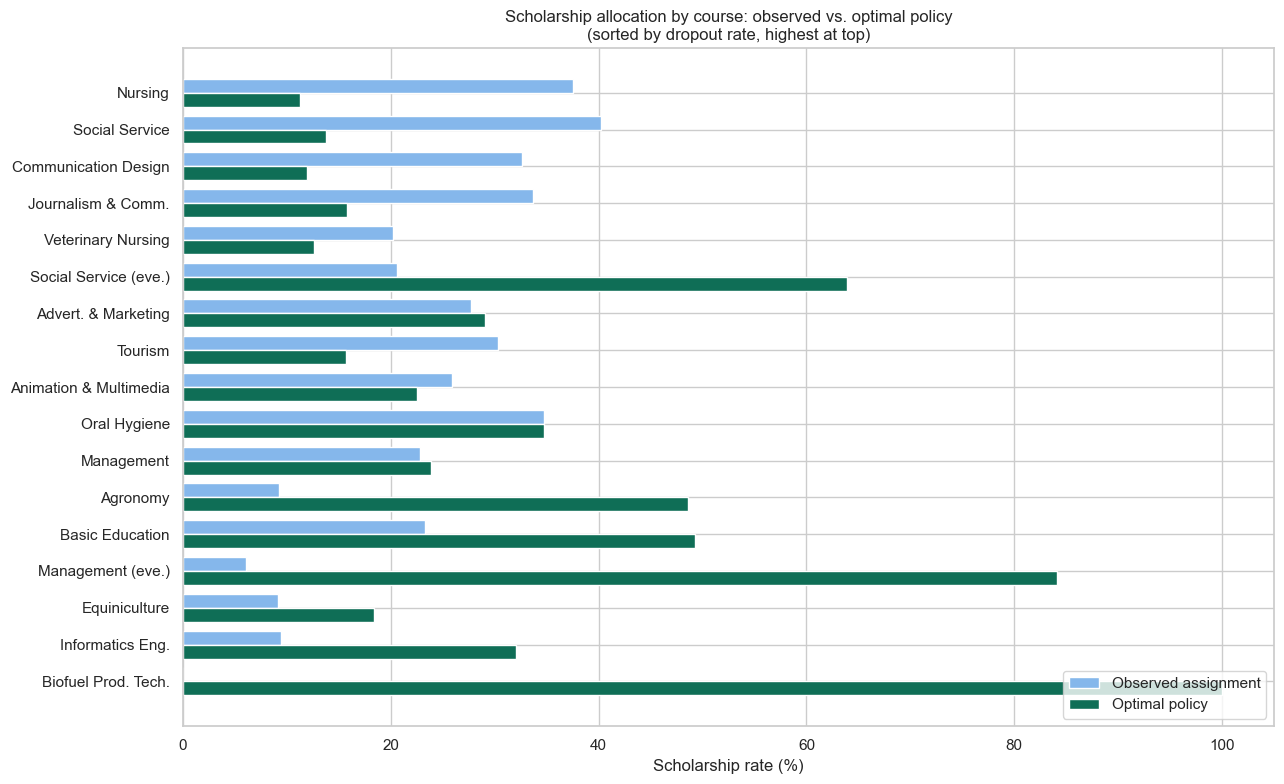

In [14]:
# Check actual course codes in the data
print("Course codes in df_resolved:", sorted(df_resolved['Course'].unique()))

course_names = {
    33:   'Biofuel Prod. Tech.',
    171:  'Animation & Multimedia',
    8014: 'Social Service (eve.)',
    9003: 'Agronomy',
    9070: 'Communication Design',
    9085: 'Veterinary Nursing',
    9119: 'Informatics Eng.',
    9130: 'Equiniculture',
    9147: 'Management',
    9238: 'Social Service',
    9254: 'Tourism',
    9500: 'Nursing',
    9556: 'Oral Hygiene',
    9670: 'Advert. & Marketing',
    9773: 'Journalism & Comm.',
    9853: 'Basic Education',
    9991: 'Management (eve.)',
}
df_resolved['Course_name'] = (df_resolved['Course']
                               .map(course_names)
                               .fillna(df_resolved['Course'].astype(str)))

course_comparison = (df_resolved
    .groupby('Course_name')
    .agg(
        obs_rate=('pi_obs', 'mean'),
        optimal_rate=('pi_star', 'mean'),
        dropout_rate_obs=('Graduate', lambda x: 1 - x.mean()),
        n_students=('Graduate', 'count'),
        mean_tau=('tau_hat', 'mean'),
    )
    .sort_values('dropout_rate_obs', ascending=False)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(13, 8))
x = np.arange(len(course_comparison))
width = 0.38

bars1 = ax.barh(x + width/2, course_comparison['obs_rate'] * 100, width,
                label='Observed assignment', color='#85B7EB')
bars2 = ax.barh(x - width/2, course_comparison['optimal_rate'] * 100, width,
                label='Optimal policy', color='#0F6E56')

ax.set_xlabel('Scholarship rate (%)')
ax.set_yticks(x)
ax.set_yticklabels(course_comparison['Course_name'])
ax.legend(loc='lower right')
ax.set_title('Scholarship allocation by course: observed vs. optimal policy\n'
             '(sorted by dropout rate, highest at top)', fontsize=12)
plt.tight_layout()
plt.show()

### 8.7 Applying the Optimal Policy to Currently Enrolled Students

The `df_enrolled` sample (~794 students) is still studying — their final outcome is unknown. We use the fitted CausalForest to predict their CATE and design an optimal scholarship allocation under a proportional budget (same scholarship rate as observed in `df_resolved`).

In [15]:
X_enrolled = df_enrolled[W_confounders].values
tau_enrolled = est.effect(X_enrolled).flatten()
mu0_enrolled = mu0_model.predict_proba(df_enrolled[W_all])[:, 1]

df_enrolled = df_enrolled.copy()
df_enrolled['tau_hat'] = tau_enrolled

# Budget for enrolled: same scholarship rate as observed in df_resolved
scholarship_rate = df_resolved[treatment].mean()
B_enrolled = int(len(df_enrolled) * scholarship_rate)

df_enrolled['rank'] = df_enrolled['tau_hat'].rank(ascending=False, method='first')
df_enrolled['pi_star'] = (df_enrolled['rank'] <= B_enrolled).astype(int)
df_enrolled['pi_obs']  = df_enrolled[treatment]

def expected_dropout(mu0, tau, pi):
    return 1 - np.mean(mu0 + tau * pi)

dropout_none    = expected_dropout(mu0_enrolled, tau_enrolled, np.zeros(len(df_enrolled)))
dropout_obs     = expected_dropout(mu0_enrolled, tau_enrolled, df_enrolled['pi_obs'].values)
dropout_optimal = expected_dropout(mu0_enrolled, tau_enrolled, df_enrolled['pi_star'].values)

print(f"Expected dropout rate among Enrolled students:")
print(f"  No scholarships:      {dropout_none*100:.1f}%")
print(f"  Current assignment:   {dropout_obs*100:.1f}%")
print(f"  Optimal assignment:   {dropout_optimal*100:.1f}%")
print(f"  Improvement:          {(dropout_obs - dropout_optimal)*100:.1f} pp")

Expected dropout rate among Enrolled students:
  No scholarships:      46.3%
  Current assignment:   42.6%
  Optimal assignment:   37.7%
  Improvement:          4.9 pp


### 8.8 Summary Visualization

Three-panel figure synthesizing all policy learning results:
1. **CATE distribution** with the budget threshold (who is at the margin)
2. **Reallocation** by course — top 8 courses with largest absolute change in scholarship rate
3. **Expected dropout** comparison for enrolled students under three policies

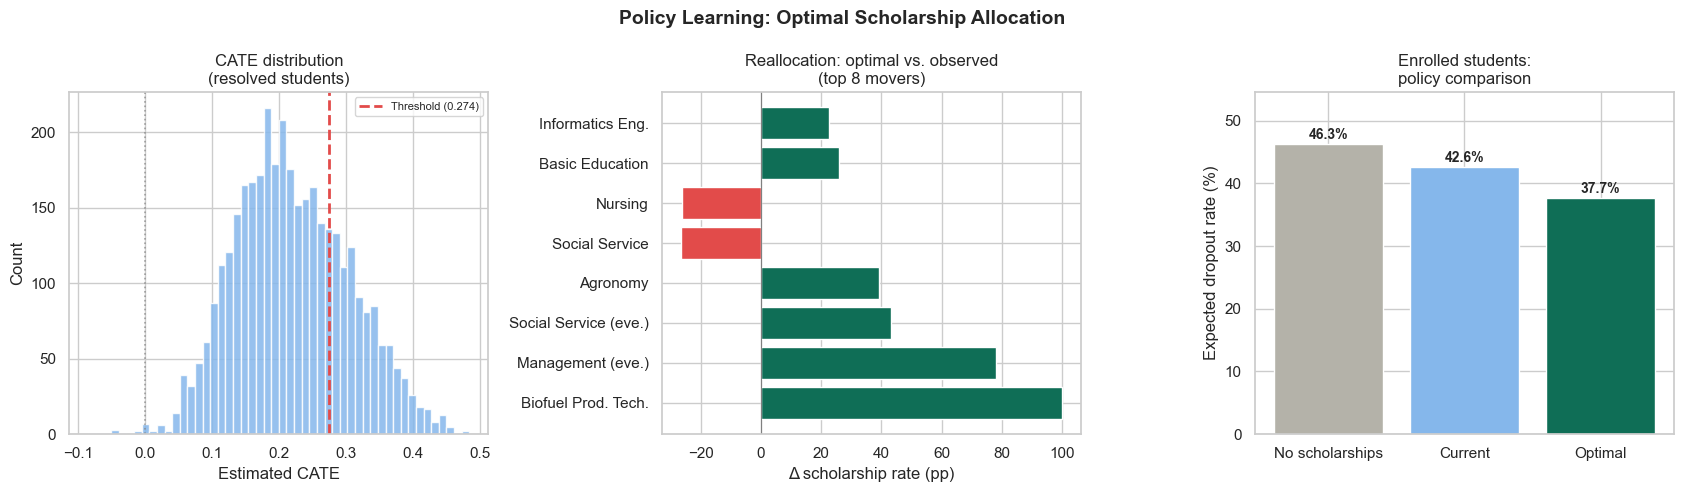

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(17, 5))
fig.suptitle('Policy Learning: Optimal Scholarship Allocation', fontsize=14, fontweight='bold')

# Panel 1: CATE distribution with budget threshold
ax = axes[0]
threshold = np.sort(tau_hat)[::-1][B - 1]
ax.hist(tau_hat, bins=50, color='#85B7EB', edgecolor='white', alpha=0.85)
ax.axvline(threshold, color='#E24B4A', linestyle='--', lw=2,
           label=f'Threshold ({threshold:.3f})')
ax.axvline(0, color='gray', linestyle=':', lw=1.2, alpha=0.7)
ax.set_xlabel('Estimated CATE')
ax.set_ylabel('Count')
ax.set_title('CATE distribution\n(resolved students)')
ax.legend(fontsize=8)

# Panel 2: Top-8 course movers (Δ = optimal - observed)
ax = axes[1]
course_comparison['delta'] = course_comparison['optimal_rate'] - course_comparison['obs_rate']
top_movers = course_comparison.reindex(
    course_comparison['delta'].abs().sort_values(ascending=False).index
).head(8)
colors = ['#0F6E56' if d > 0 else '#E24B4A' for d in top_movers['delta']]
ax.barh(top_movers['Course_name'], top_movers['delta'] * 100, color=colors)
ax.set_xlabel('Δ scholarship rate (pp)')
ax.set_title('Reallocation: optimal vs. observed\n(top 8 movers)')
ax.axvline(0, color='gray', linewidth=0.8)

# Panel 3: Expected dropout comparison (enrolled students)
ax = axes[2]
labels_bar = ['No scholarships', 'Current', 'Optimal']
values_bar = [dropout_none * 100, dropout_obs * 100, dropout_optimal * 100]
bar_colors = ['#B4B2A9', '#85B7EB', '#0F6E56']
bars = ax.bar(labels_bar, values_bar, color=bar_colors)
for bar, val in zip(bars, values_bar):
    ax.text(bar.get_x() + bar.get_width() / 2, bar.get_height() + 0.3,
            f'{val:.1f}%', ha='center', va='bottom', fontsize=10, fontweight='bold')
ax.set_ylabel('Expected dropout rate (%)')
ax.set_title('Enrolled students:\npolicy comparison')
ax.set_ylim(0, max(values_bar) * 1.18)

plt.tight_layout()
plt.show()